In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("FinShield_UPI_Fraud_Transaction.csv")
df.head()

,Transaction_ID,Transaction_Date,Sender_ID,Receiver_ID,Sender_Bank,Receiver_Bank,City,Device_Type,Transaction_Type,Amount_INR,...,Account_Age_Days,Transactions_Last_24H,Avg_Transaction_Amount_7D,Failed_Transactions_24H,IP_Risk_Score,Device_Risk_Score,Location_Change_KM,Fraud_Reason,Fraud_Label,Is_Fraud
0,UPI1000000,01-01-25 0:00,CUST25795,MER1304,Kotak,ICICI,Hyderabad,Android,UPI ID,391.82,...,184,4,341.75,0,17.27,97.32,0.17,Normal Activity,Legitimate,0
1,UPI1000001,01-01-25 0:10,CUST10860,MER6138,Canara Bank,Bank of Baroda,Pune,Web,QR Code,137.03,...,2770,2,98.11,0,27.67,11.15,10.00,Normal Activity,Legitimate,0
2,UPI1000002,01-01-25 0:20,CUST86820,MER4454,ICICI,SBI,Hyderabad,iOS,QR Code,544.46,...,1323,6,618.52,1,30.78,22.84,2.99,Normal Activity,Legitimate,0
3,UPI1000003,01-01-25 0:30,CUST64886,MER7082,Bank of Baroda,SBI,Chennai,Android,QR Code,292.36,...,1507,10,180.76,0,98.58,32.13,0.78,Normal Activity,Legitimate,0
4,UPI1000004,01-01-25 0:40,CUST16265,MER6349,PNB,Bank of Baroda,Ahmedabad,Android,QR Code,471.73,...,1613,0,262.58,0,9.12,86.92,1.59,Normal Activity,Legitimate,0


# Data Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             50000 non-null  object 
 1   Transaction_Date           50000 non-null  object 
 2   Sender_ID                  50000 non-null  object 
 3   Receiver_ID                50000 non-null  object 
 4   Sender_Bank                50000 non-null  object 
 5   Receiver_Bank              50000 non-null  object 
 6   City                       50000 non-null  object 
 7   Device_Type                50000 non-null  object 
 8   Transaction_Type           50000 non-null  object 
 9   Amount_INR                 50000 non-null  float64
 10  Transaction_Status         50000 non-null  object 
 11  Account_Age_Days           50000 non-null  int64  
 12  Transactions_Last_24H      50000 non-null  int64  
 13  Avg_Transaction_Amount_7D  50000 non-null  flo

In [4]:
df.describe()

,Amount_INR,Account_Age_Days,Transactions_Last_24H,Avg_Transaction_Amount_7D,Failed_Transactions_24H,IP_Risk_Score,Device_Risk_Score,Location_Change_KM,Is_Fraud
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,815.528995,1499.974700,4.009500,498.755110,0.500840,50.089696,50.031216,7.957315,0.055880
std,1078.387992,862.334396,1.995367,356.092353,0.710668,28.861210,28.804304,8.007403,0.229692
min,8.510000,10.000000,0.000000,17.710000,0.000000,0.010000,0.010000,0.000000,0.000000
25%,251.807500,750.000000,3.000000,261.150000,0.000000,25.257500,25.180000,2.300000,0.000000
50%,493.720000,1501.000000,4.000000,404.725000,0.000000,50.025000,50.075000,5.480000,0.000000
75%,966.372500,2240.000000,5.000000,627.035000,1.000000,75.150000,74.940000,11.010000,0.000000
max,38631.760000,2999.000000,14.000000,4054.290000,6.000000,100.000000,100.000000,78.430000,1.000000


In [5]:
df.shape

(50000, 21)

### Data Types Check

In [6]:
df['Transaction_Date']= pd.to_datetime(df['Transaction_Date'],errors='coerce')

### Missing value

In [7]:
df.isna().sum().sum()

np.int64(0)

In [8]:
(df.isnull().sum() / len(df) * 100)

Transaction_ID               0.0
Transaction_Date             0.0
Sender_ID                    0.0
Receiver_ID                  0.0
Sender_Bank                  0.0
Receiver_Bank                0.0
City                         0.0
Device_Type                  0.0
Transaction_Type             0.0
Amount_INR                   0.0
Transaction_Status           0.0
Account_Age_Days             0.0
Transactions_Last_24H        0.0
Avg_Transaction_Amount_7D    0.0
Failed_Transactions_24H      0.0
IP_Risk_Score                0.0
Device_Risk_Score            0.0
Location_Change_KM           0.0
Fraud_Reason                 0.0
Fraud_Label                  0.0
Is_Fraud                     0.0
dtype: float64

### Duplicate values

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Transaction_ID'].duplicated().sum()

np.int64(0)

### Spelling Error

In [11]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print("\n", col)
    print(df[col].unique())


 Transaction_ID
['UPI1000000' 'UPI1000001' 'UPI1000002' ... 'UPI1049997' 'UPI1049998'
 'UPI1049999']

 Sender_ID
['CUST25795' 'CUST10860' 'CUST86820' ... 'CUST19398' 'CUST71140'
 'CUST14518']

 Receiver_ID
['MER1304' 'MER6138' 'MER4454' ... 'MER6448' 'MER9199' 'MER7370']

 Sender_Bank
['Kotak' 'Canara Bank' 'ICICI' 'Bank of Baroda' 'PNB' 'Axis' 'SBI' 'HDFC']

 Receiver_Bank
['ICICI' 'Bank of Baroda' 'SBI' 'PNB' 'Kotak' 'Canara Bank' 'Axis' 'HDFC']

 City
['Hyderabad' 'Pune' 'Chennai' 'Ahmedabad' 'Kolkata' 'Mumbai' 'Bengaluru'
 'Delhi' 'Jaipur' 'Bhopal']

 Device_Type
['Android' 'Web' 'iOS']

 Transaction_Type
['UPI ID' 'QR Code' 'Collect Request' 'Mobile Number']

 Transaction_Status
['Success' 'Failed' 'Pending' 'Reversed']

 Fraud_Reason
['Normal Activity' 'High IP & Device Risk' 'Unusual Transaction Amount'
 'Multiple Failed Transactions' 'Unusual Location Change'
 'Unusual Transaction Frequency']

 Fraud_Label
['Legitimate' 'Fraud']


In [12]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 Transaction_ID
Transaction_ID
UPI1000000    1
UPI1000001    1
UPI1000002    1
UPI1000003    1
UPI1000004    1
             ..
UPI1049995    1
UPI1049996    1
UPI1049997    1
UPI1049998    1
UPI1049999    1
Name: count, Length: 50000, dtype: int64

 Sender_ID
Sender_ID
CUST10645    7
CUST62142    5
CUST33386    5
CUST85450    5
CUST79519    5
            ..
CUST69100    1
CUST86350    1
CUST71924    1
CUST58406    1
CUST87132    1
Name: count, Length: 38312, dtype: int64

 Receiver_ID
Receiver_ID
MER7588    16
MER2915    15
MER8463    15
MER5294    15
MER9876    15
           ..
MER5498     1
MER9764     1
MER8519     1
MER9199     1
MER7370     1
Name: count, Length: 8968, dtype: int64

 Sender_Bank
Sender_Bank
Kotak             6344
Bank of Baroda    6311
HDFC              6282
Axis              6269
Canara Bank       6236
ICICI             6235
SBI               6167
PNB               6156
Name: count, dtype: int64

 Receiver_Bank
Receiver_Bank
Canara Bank       6343
Kotak         

### Checking the inconsistent formatting - spaces,case

In [13]:
for col in cat_cols:
    mask = df[col] != df[col].str.strip()
    if mask.any():
        print(col)
        print(f"{df.loc[mask, col].unique()}\n")

### Hidden space 

In [14]:
for col in cat_cols:
    print(col)
    print(repr(df[col].unique()))
    print("\n")

Transaction_ID
array(['UPI1000000', 'UPI1000001', 'UPI1000002', ..., 'UPI1049997',
       'UPI1049998', 'UPI1049999'], shape=(50000,), dtype=object)


Sender_ID
array(['CUST25795', 'CUST10860', 'CUST86820', ..., 'CUST19398',
       'CUST71140', 'CUST14518'], shape=(38312,), dtype=object)


Receiver_ID
array(['MER1304', 'MER6138', 'MER4454', ..., 'MER6448', 'MER9199',
       'MER7370'], shape=(8968,), dtype=object)


Sender_Bank
array(['Kotak', 'Canara Bank', 'ICICI', 'Bank of Baroda', 'PNB', 'Axis',
       'SBI', 'HDFC'], dtype=object)


Receiver_Bank
array(['ICICI', 'Bank of Baroda', 'SBI', 'PNB', 'Kotak', 'Canara Bank',
       'Axis', 'HDFC'], dtype=object)


City
array(['Hyderabad', 'Pune', 'Chennai', 'Ahmedabad', 'Kolkata', 'Mumbai',
       'Bengaluru', 'Delhi', 'Jaipur', 'Bhopal'], dtype=object)


Device_Type
array(['Android', 'Web', 'iOS'], dtype=object)


Transaction_Type
array(['UPI ID', 'QR Code', 'Collect Request', 'Mobile Number'],
      dtype=object)


Transaction_Status
ar

### Fix extra spaces 

In [15]:
# for col in cat_cols:
#     df[col] = df[col].str.strip()

In [16]:
for col in df.select_dtypes('object'):
    mask = df[col].astype(str) != df[col].astype(str).str.strip()
    if mask.any(): print(col, df.loc[mask, col].unique())

### checking range and invalid values

In [17]:
rules = {
    'Amount_INR': (0,50000),
    'Account_Age_Days': (0,4000),
    'Transactions_Last_24H': (0,20),
    'Avg_Transaction_Amount_7D':(0,100000),
    'Failed_Transactions_24H':(0,10),
    'IP_Risk_Score':(0,100),
    'Device_Risk_Score':(0,100),
    'Location_Change_KM':(0,100),
    'Is_Fraud':(0,1)
}

for col,(low,high) in rules.items():
    invalid = df[~df[col].between(low,high)]
    print(f"{col}: {len(invalid)} invalid values")

Amount_INR: 0 invalid values
Account_Age_Days: 0 invalid values
Transactions_Last_24H: 0 invalid values
Avg_Transaction_Amount_7D: 0 invalid values
Failed_Transactions_24H: 0 invalid values
IP_Risk_Score: 0 invalid values
Device_Risk_Score: 0 invalid values
Location_Change_KM: 0 invalid values
Is_Fraud: 0 invalid values


### outliers

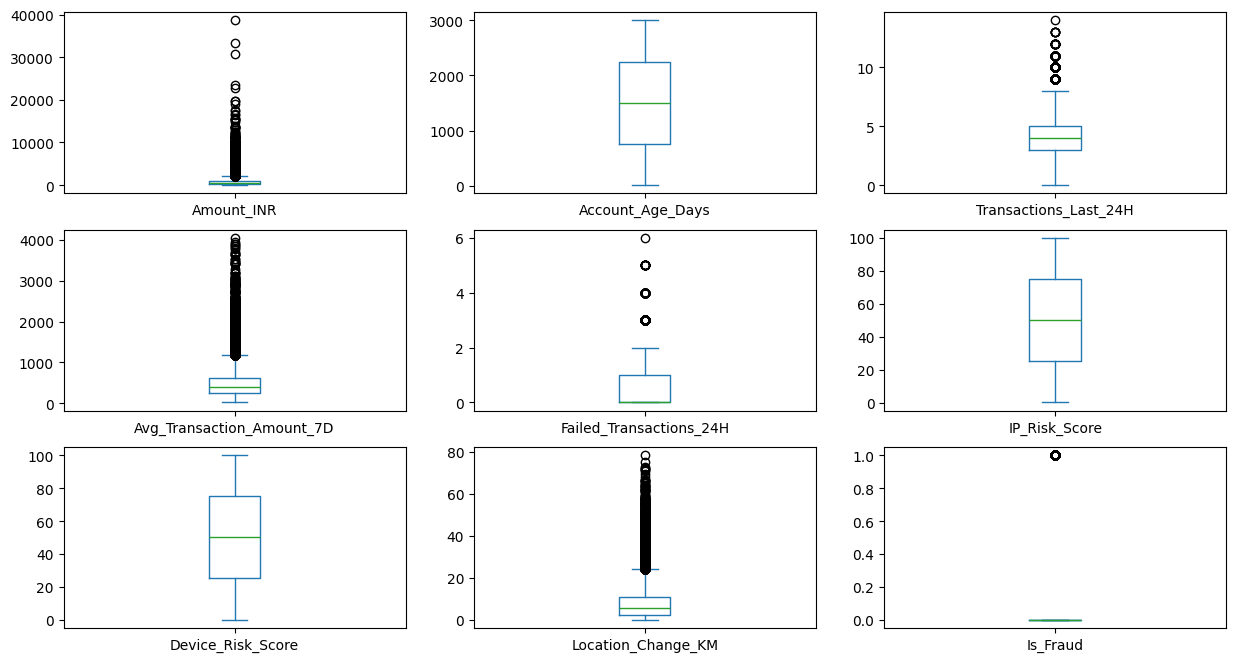

In [18]:
df.select_dtypes(include='number').plot(
    kind='box',
    subplots=True,
    layout=(-1,3),
    figsize=(15,8)
)
plt.show()

In [19]:
def detect_out():
    data = df.select_dtypes(include='number')

    for i in data:
        data=df[i].dropna()
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data < lower) | (data > upper)]

        print("\ncolumn", i)
        print("no_outlier :", len(outliers))
        
        if len(outliers)>0:
            print(outliers)
detect_out()


column Amount_INR
no_outlier : 3894
12       2802.73
39       2355.54
46       2969.27
51       2187.43
55       2112.76
          ...   
49944    3227.46
49966    4257.88
49983    2427.68
49984    3176.31
49989    7423.72
Name: Amount_INR, Length: 3894, dtype: float64

column Account_Age_Days
no_outlier : 0

column Transactions_Last_24H
no_outlier : 1066
3        10
61        9
104       9
135       9
158       9
         ..
49661    10
49800    10
49884     9
49902     9
49998    10
Name: Transactions_Last_24H, Length: 1066, dtype: int64

column Avg_Transaction_Amount_7D
no_outlier : 2526
13       1267.28
25       1432.43
33       1190.36
74       1352.46
81       1292.94
          ...   
49875    1333.90
49902    1249.07
49958    1969.57
49970    1719.99
49976    1183.80
Name: Avg_Transaction_Amount_7D, Length: 2526, dtype: float64

column Failed_Transactions_24H
no_outlier : 724
61       3
180      3
205      3
246      3
256      3
        ..
49773    3
49907    4
49918    3
4993

In [20]:
df.loc[df['Amount_INR'].idxmax(), ['Amount_INR', 'Transaction_Type']]

Amount_INR          38631.76
Transaction_Type     QR Code
Name: 23561, dtype: object

In [21]:
df['Transactions_Last_24H'].max()

np.int64(14)

In [22]:
df['Location_Change_KM'].max()

np.float64(78.43)

In [23]:
df.loc[df['Account_Age_Days'].idxmax(), ['Account_Age_Days']]

Account_Age_Days    2999
Name: 5462, dtype: object

In [24]:
df['Device_Risk_Score'].min()

np.float64(0.01)

In [25]:
df.loc[df['Amount_INR'].idxmin(), ['Amount_INR', 'Transaction_Type']]

Amount_INR                     8.51
Transaction_Type    Collect Request
Name: 3231, dtype: object

In [26]:
df['IP_Risk_Score'].max()

np.float64(100.0)

In [27]:
df['Avg_Transaction_Amount_7D'].max()

np.float64(4054.29)

### Fraud-Label Consistency

In [28]:
df['Fraud_Label'].value_counts(dropna=False)

Fraud_Label
Legitimate    47206
Fraud          2794
Name: count, dtype: int64

In [29]:
df['Fraud_Reason'].value_counts(dropna=False)

Fraud_Reason
Normal Activity                  49193
High IP & Device Risk              484
Unusual Transaction Amount         261
Multiple Failed Transactions        50
Unusual Location Change             11
Unusual Transaction Frequency        1
Name: count, dtype: int64

In [30]:
pd.crosstab(df['Fraud_Label'], df['Fraud_Reason'])

Fraud_Reason,High IP & Device Risk,Multiple Failed Transactions,Normal Activity,Unusual Location Change,Unusual Transaction Amount,Unusual Transaction Frequency
Fraud_Label,,,,,,
Fraud,484,50,1987,11,261,1
Legitimate,0,0,47206,0,0,0


In [31]:
pd.crosstab( df['Fraud_Label'], df['Transaction_Status'])

Transaction_Status,Failed,Pending,Reversed,Success
Fraud_Label,,,,
Fraud,183,123,45,2443
Legitimate,2722,1862,921,41701


<Axes: >

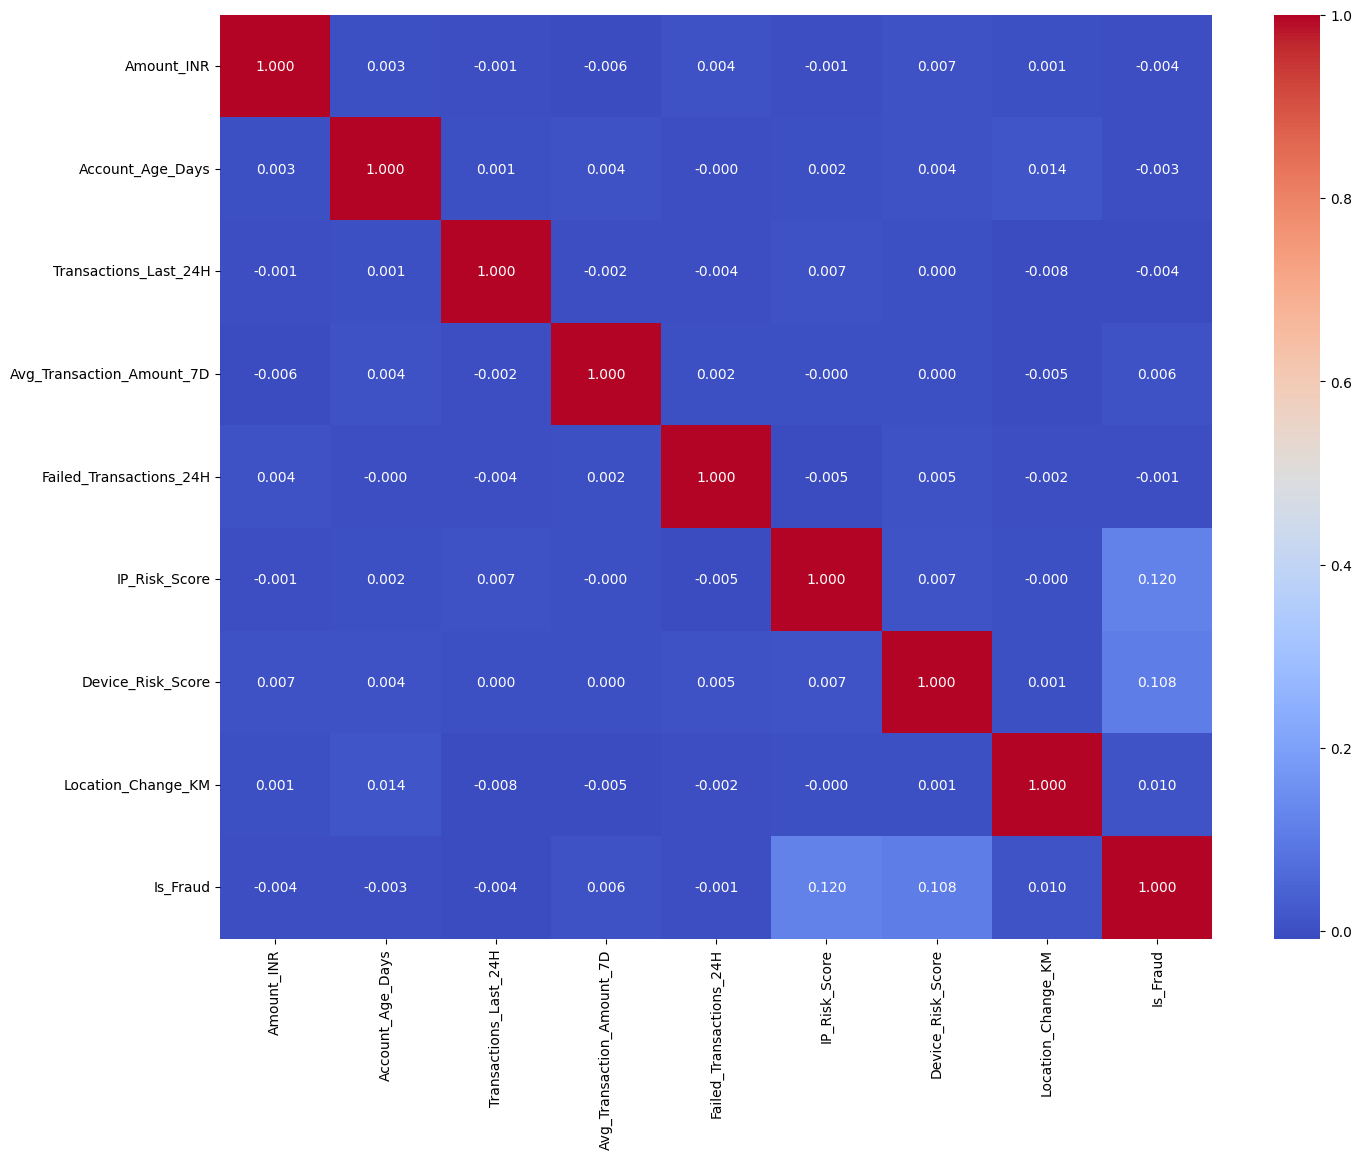

In [32]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True ,fmt=".3f", cmap="coolwarm" )

In [33]:
df.to_csv("FinShield_UPI_Fraud_Transaction_cleaned.csv",index=False)

# Univariate Analysis

## Basic overview

In [34]:
# Total Transaction
Total_Transaction = df['Transaction_ID'].count()
Total_Transaction

np.int64(50000)

In [35]:
# Total Transaction Amount
Total_Transaction_amount = df['Amount_INR'].sum()
Total_Transaction_amount

np.float64(40776449.769999996)

In [36]:
# Total Fraud Transaction 
Total_Fraud_Transaction  = (df['Is_Fraud']==1).sum()
Total_Fraud_Transaction 

np.int64(2794)

In [37]:
# Fraud Transaction Amount
Total_Fraud_amount = df[df['Is_Fraud']==1] [['Amount_INR']].sum()
Total_Fraud_amount

Amount_INR    2231947.04
dtype: float64

In [38]:
# fraud_amount % 
Fraud_amount_pct = Fraud_amount/Total_Transaction_amount*100
Fraud_amount_pct

NameError: name 'Fraud_amount' is not defined

In [ ]:
# fraud_rate % 
Fraud_rate_pct  = Total_Fraud_Transaction/Total_Transaction*100
Fraud_rate_pct

In [ ]:
# Average Fraud transaction Amount
Avg_fraud_transaction_Amount = df[df['Is_Fraud']==1] [['Amount_INR']].mean()
Avg_fraud_transaction_Amount

## Transactional Analysis

In [ ]:
# Fraud by Transaction_Type
pd.crosstab(df['Transaction_Type'],df['Is_Fraud'])

In [ ]:
ax = df['Transaction_Type'].value_counts().plot(kind='bar')
print(ax.bar_label(ax.containers[0]))

In [ ]:
ax =pd.crosstab(df['Transaction_Type'],df['Is_Fraud']).plot(kind='bar')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

In [ ]:
ax = df['Transaction_Status'].value_counts().plot(kind='bar')
print(ax.bar_label(ax.containers[0]))

In [ ]:
# Fraud by Transaction_Status
ax = pd.crosstab(df['Transaction_Status'],df['Is_Fraud']).plot(kind='bar')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

In [ ]:
# Fraud by Transactions_Last_24H
ax = pd.crosstab(df['Transactions_Last_24H'], df['Is_Fraud']).plot(kind='bar')
ax.bar_label(ax.containers[0], fontsize = 7)
ax.bar_label(ax.containers[1], fontsize = 7)
plt.tight_layout()
plt.show()

In [ ]:
# Fraud by location change
sns.boxplot(data=df, x='Is_Fraud', y='Location_Change_KM')
plt.show()

In [ ]:
# Fraud by Device type
ax = sns.countplot(data=df, x='Device_Type', hue='Is_Fraud')
ax.bar_label(ax.containers[0])
plt.show()

## Risk Analysis

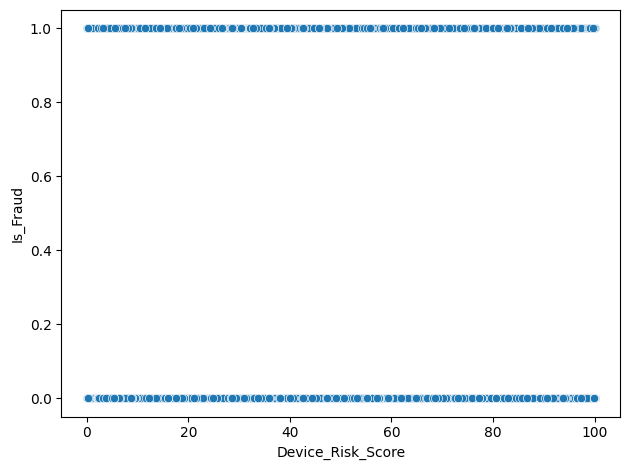

In [39]:
# Fraud by Device_Risk_Score
sns.scatterplot(x=df['Device_Risk_Score'], y=df['Is_Fraud'])
plt.tight_layout()
plt.show()

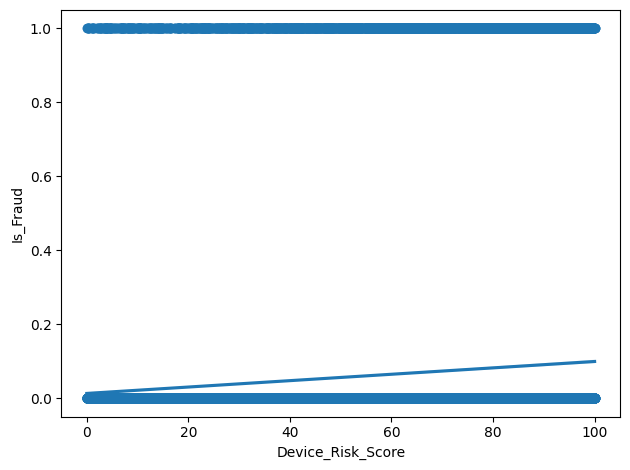

In [40]:
# Fraud by IP_Risk_Score
sns.regplot(x=df['Device_Risk_Score'], y=df['Is_Fraud'])
plt.tight_layout()
plt.show()

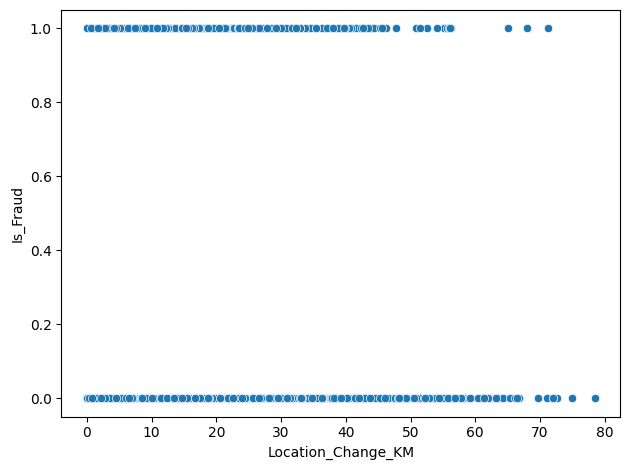

In [41]:
# Fraud by Location_Change_KM
sns.scatterplot(x=df['Location_Change_KM'], y=df['Is_Fraud'])
plt.tight_layout()
plt.show()

## Location/Time Analysis

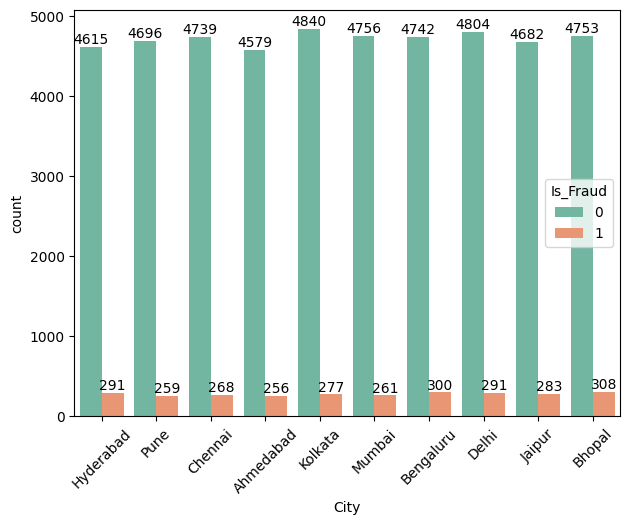

In [42]:
# Fraud by City
ax = sns.countplot(x=df['City'], hue =df['Is_Fraud'] ,  palette='Set2')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

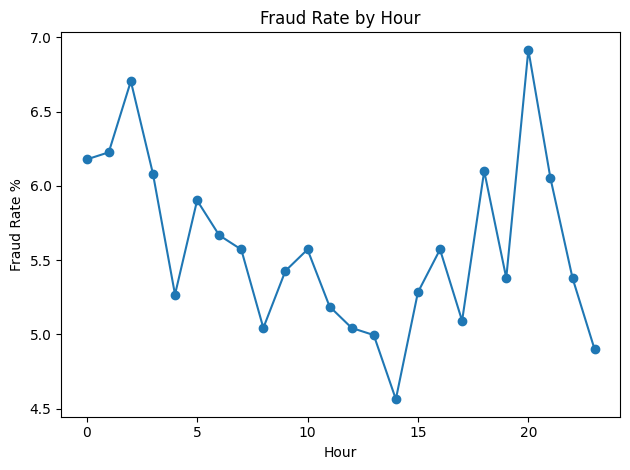

In [43]:
# Fraud Rate by Hour
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
hour_fraud = df.groupby(df['Transaction_Date'].dt.hour)['Is_Fraud'].mean() * 100

ax = hour_fraud.plot(kind='line', marker='o')
ax.set_xlabel('Hour')
ax.set_ylabel('Fraud Rate %')
ax.set_title('Fraud Rate by Hour')
plt.tight_layout()
plt.show()

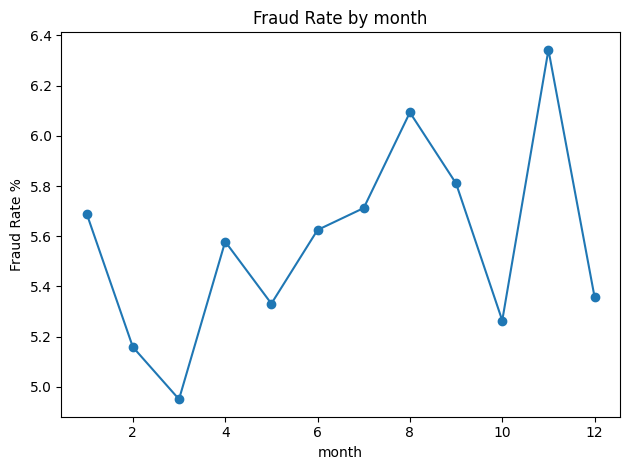

In [44]:
# Fraud Rate by month
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
hour_fraud = df.groupby(df['Transaction_Date'].dt.month)['Is_Fraud'].mean() * 100

ax = hour_fraud.plot(kind='line', marker='o')
ax.set_xlabel('month')
ax.set_ylabel('Fraud Rate %')
ax.set_title('Fraud Rate by month')
plt.tight_layout()
plt.show()

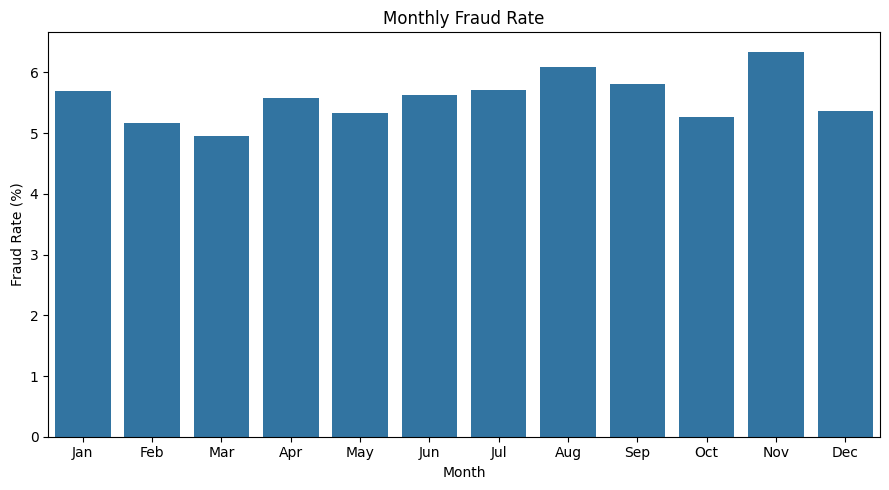

In [45]:
df['Transaction_Date']=pd.to_datetime(df['Transaction_Date'])
monthly_fraud = (
    df.groupby(df['Transaction_Date'].dt.month)['Is_Fraud']
      .mean()
      .mul(100)
)

monthly_fraud.index = monthly_fraud.index.map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
})

plt.figure(figsize=(9,5))
sns.barplot(x=monthly_fraud.index, y=monthly_fraud.values)

plt.title('Monthly Fraud Rate')
plt.xlabel('Month')
plt.ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

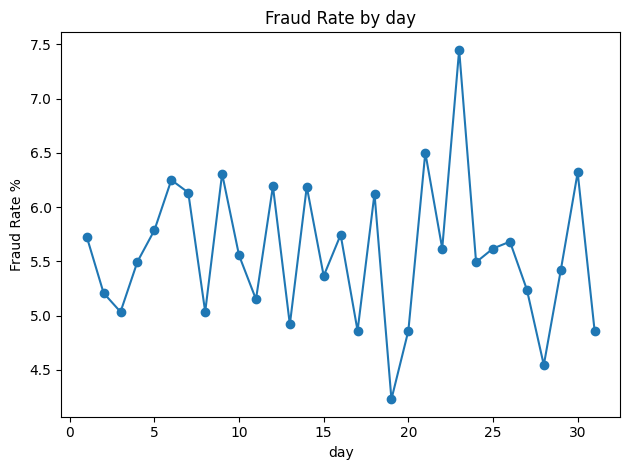

In [46]:
# Fraud Rate by day
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
hour_fraud = df.groupby(df['Transaction_Date'].dt.day)['Is_Fraud'].mean() * 100

ax = hour_fraud.plot(kind='line', marker='o')
ax.set_xlabel('day')
ax.set_ylabel('Fraud Rate %')
ax.set_title('Fraud Rate by day')
plt.tight_layout()
plt.show()

In [47]:
# Fraud Rate by Transaction Type
fraud_rate_type = (
    df.groupby('Transaction_Type')['Is_Fraud']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_type

Transaction_Type
Collect Request    7.395751
UPI ID             5.421324
QR Code            5.408889
Mobile Number      5.230769
Name: Is_Fraud, dtype: float64

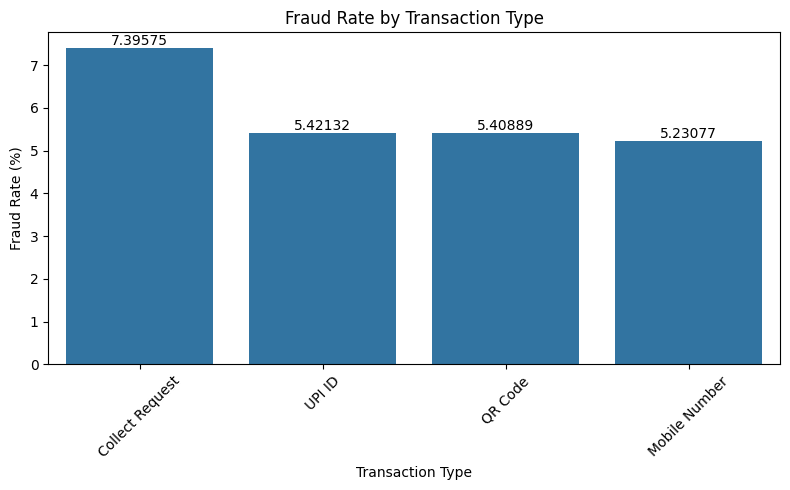

In [48]:
plt.figure(figsize=(8,5))
ax = sns.barplot(x=fraud_rate_type.index, y=fraud_rate_type.values)
ax.bar_label(ax.containers[0])
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
# Fraud Rate by Device Type
fraud_rate_device = (
    df.groupby('Device_Type')['Is_Fraud']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

fraud_rate_device

Device_Type
Web        9.130957
Android    5.417381
iOS        5.358141
Name: Is_Fraud, dtype: float64

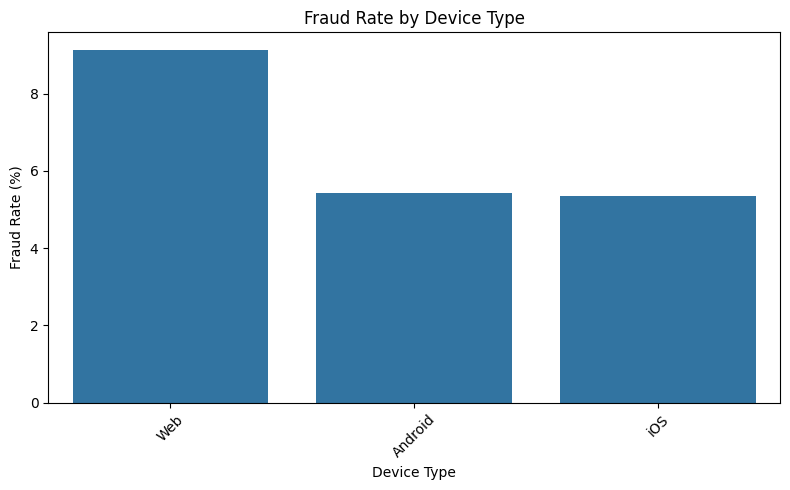

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(x=fraud_rate_device.index, y=fraud_rate_device.values)

plt.title('Fraud Rate by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
fraud_rate_city = (
    df.groupby('City')['Is_Fraud']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .head(10)
)

fraud_rate_city

City
Bhopal       6.085754
Bengaluru    5.950020
Hyderabad    5.931512
Delhi        5.711482
Jaipur       5.699899
Kolkata      5.413328
Chennai      5.352506
Ahmedabad    5.294726
Pune         5.227043
Mumbai       5.202312
Name: Is_Fraud, dtype: float64

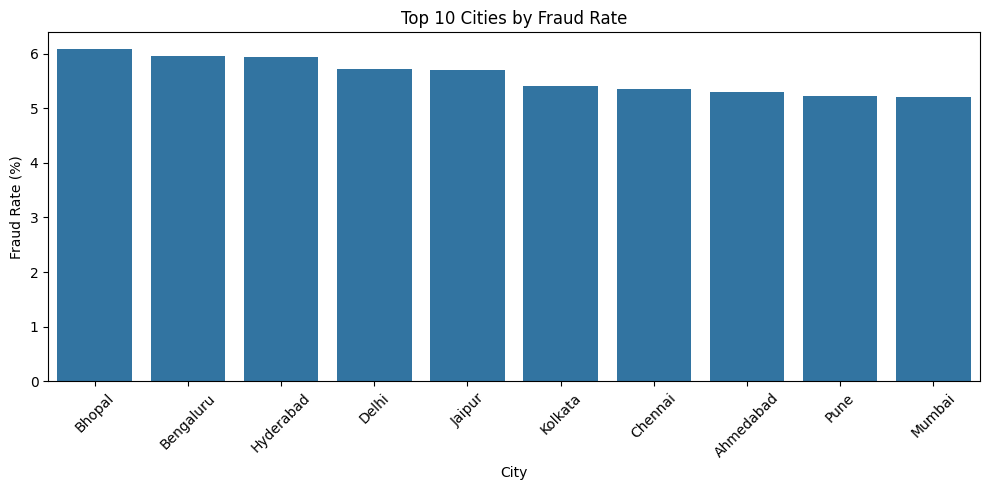

In [52]:
# . Fraud Rate by City
plt.figure(figsize=(10,5))
sns.barplot(x=fraud_rate_city.index, y=fraud_rate_city.values)

plt.title('Top 10 Cities by Fraud Rate')
plt.xlabel('City')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
# Fraud by Failed Transaction 
failed_fraud = (
    df.groupby('Failed_Transactions_24H')['Is_Fraud']
      .mean()
      .mul(100)
)

failed_fraud

Failed_Transactions_24H
0      5.676468
1      5.435216
2      4.954604
3      8.386076
4      6.666667
5     12.500000
6    100.000000
Name: Is_Fraud, dtype: float64

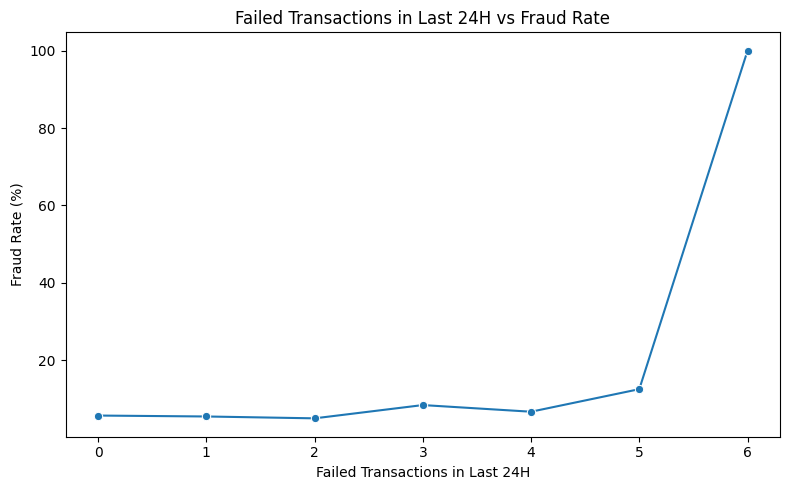

In [54]:
plt.figure(figsize=(8,5))
sns.lineplot(x=failed_fraud.index, y=failed_fraud.values, marker='o')

plt.title('Failed Transactions in Last 24H vs Fraud Rate')
plt.xlabel('Failed Transactions in Last 24H')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

In [55]:
# Fraud by High-Value Transaction
df['Amount_Band'] = pd.cut(
    df['Amount_INR'],
    bins=[0, 500, 1000, 5000, 10000, float('inf')],
    labels=['0-500', '501-1000', '1001-5000', '5001-10000', '10000+']
)
amount_fraud = (
    df.groupby('Amount_Band', observed=True)['Is_Fraud']
      .mean()
      .mul(100)
)

amount_fraud

Amount_Band
0-500         5.752545
501-1000      5.368134
1001-5000     5.475605
5001-10000    5.341880
10000+        6.666667
Name: Is_Fraud, dtype: float64

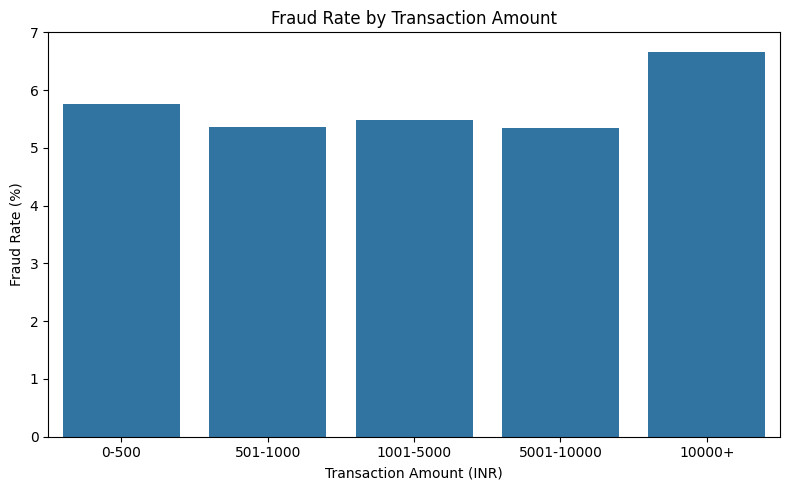

In [56]:
plt.figure(figsize=(8,5))
sns.barplot(x=amount_fraud.index, y=amount_fraud.values)

plt.title('Fraud Rate by Transaction Amount')
plt.xlabel('Transaction Amount (INR)')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

In [57]:
# Risk Score vs Fraud Rate
df['IP_Risk_Band'] = pd.cut(
    df['IP_Risk_Score'],
    bins=[-1, 20, 40, 60, 80, 100],
    labels=['0-20', '21-40', '41-60', '61-80', '81-100']
)
ip_risk_fraud = (
    df.groupby('IP_Risk_Band', observed=True)['Is_Fraud']
      .mean()
      .mul(100)
)

ip_risk_fraud

IP_Risk_Band
0-20       2.524135
21-40      3.451345
41-60      4.820616
61-80      6.686627
81-100    10.439725
Name: Is_Fraud, dtype: float64

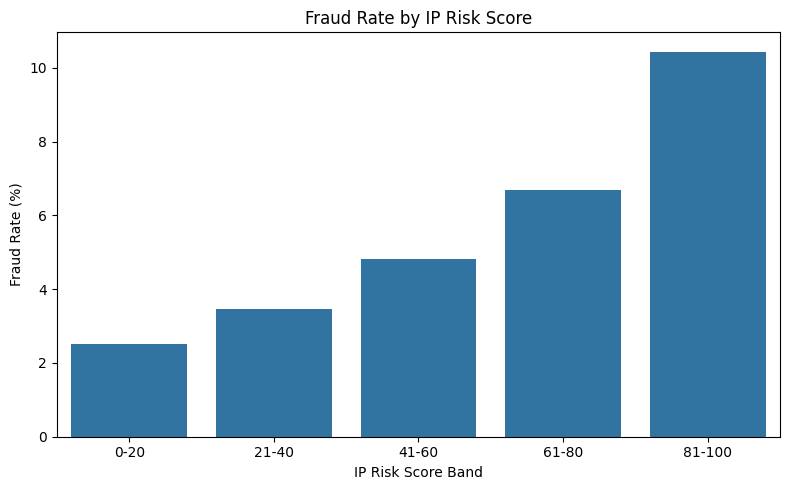

In [58]:
plt.figure(figsize=(8,5))
sns.barplot(x=ip_risk_fraud.index, y=ip_risk_fraud.values)

plt.title('Fraud Rate by IP Risk Score')
plt.xlabel('IP Risk Score Band')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

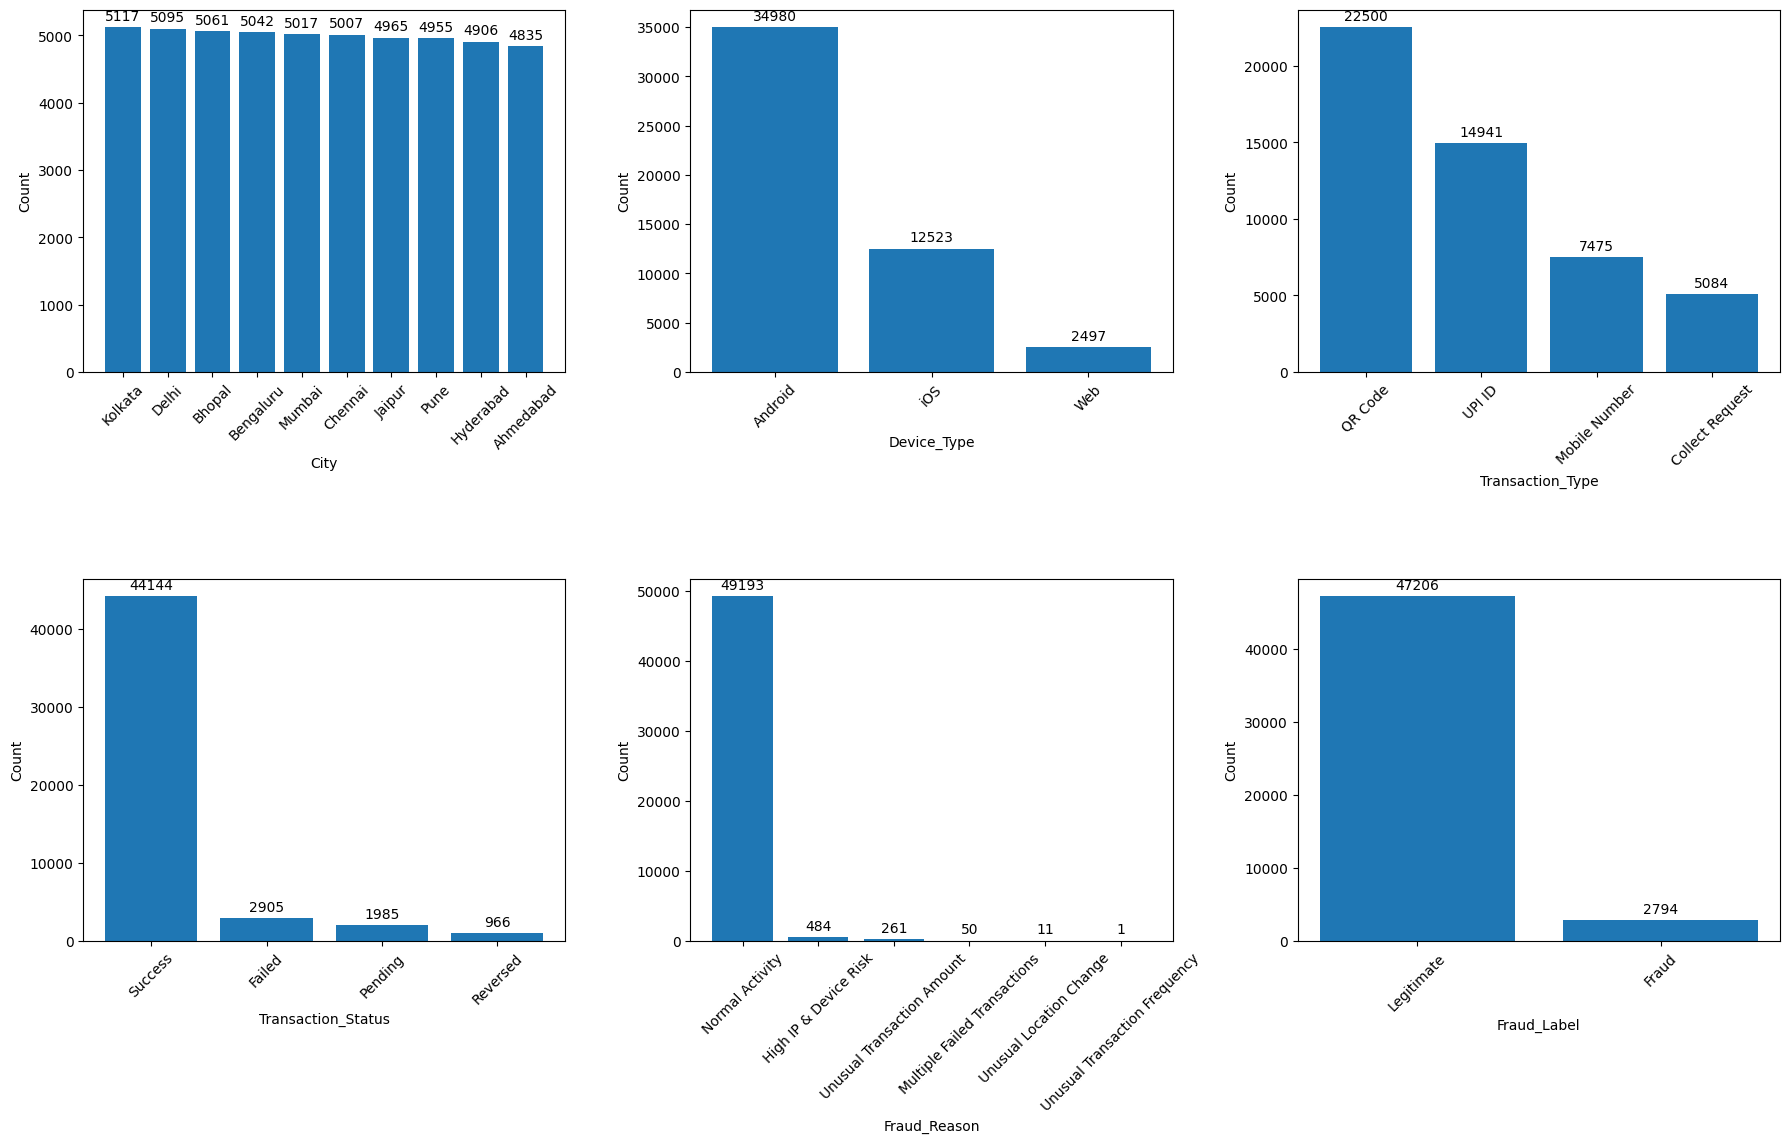

In [59]:
category_cols = [ 'City', 'Device_Type', 'Transaction_Type', 'Transaction_Status', 'Fraud_Reason', 'Fraud_Label']

plt.figure(figsize=(18, 21))

for index, i in enumerate(category_cols):
    
    plt.subplot(4, 3, index + 1)
    counts = df[i].value_counts().head(10)
    ax = plt.bar(counts.index, counts.values)
    plt.bar_label(ax, padding=3)
    
    plt.xlabel(i)
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

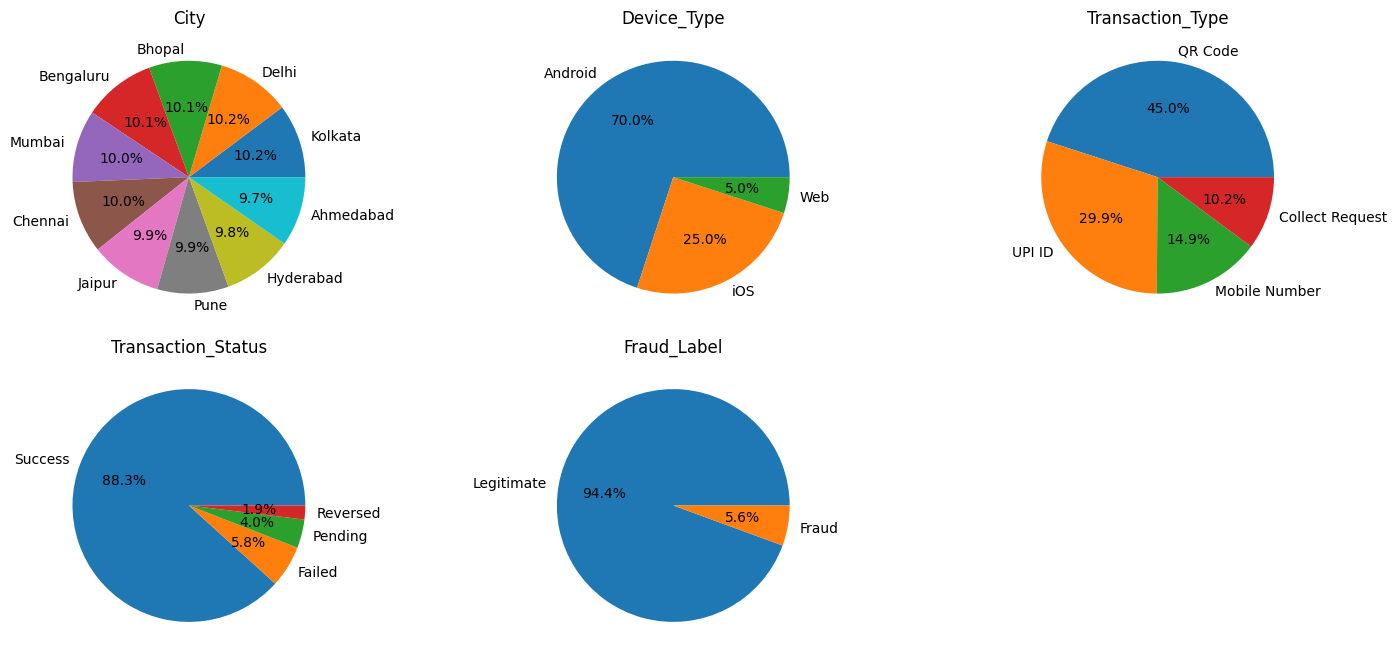

In [60]:
category_cols = [ 'City', 'Device_Type', 'Transaction_Type', 'Transaction_Status', 'Fraud_Label']

plt.figure(figsize=(15,10))

for index, i in enumerate(category_cols):
    plt.subplot(3,3,index+1)

    df[i].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%'
    )

    plt.title(i)
    plt.ylabel("")

plt.tight_layout()
plt.show()

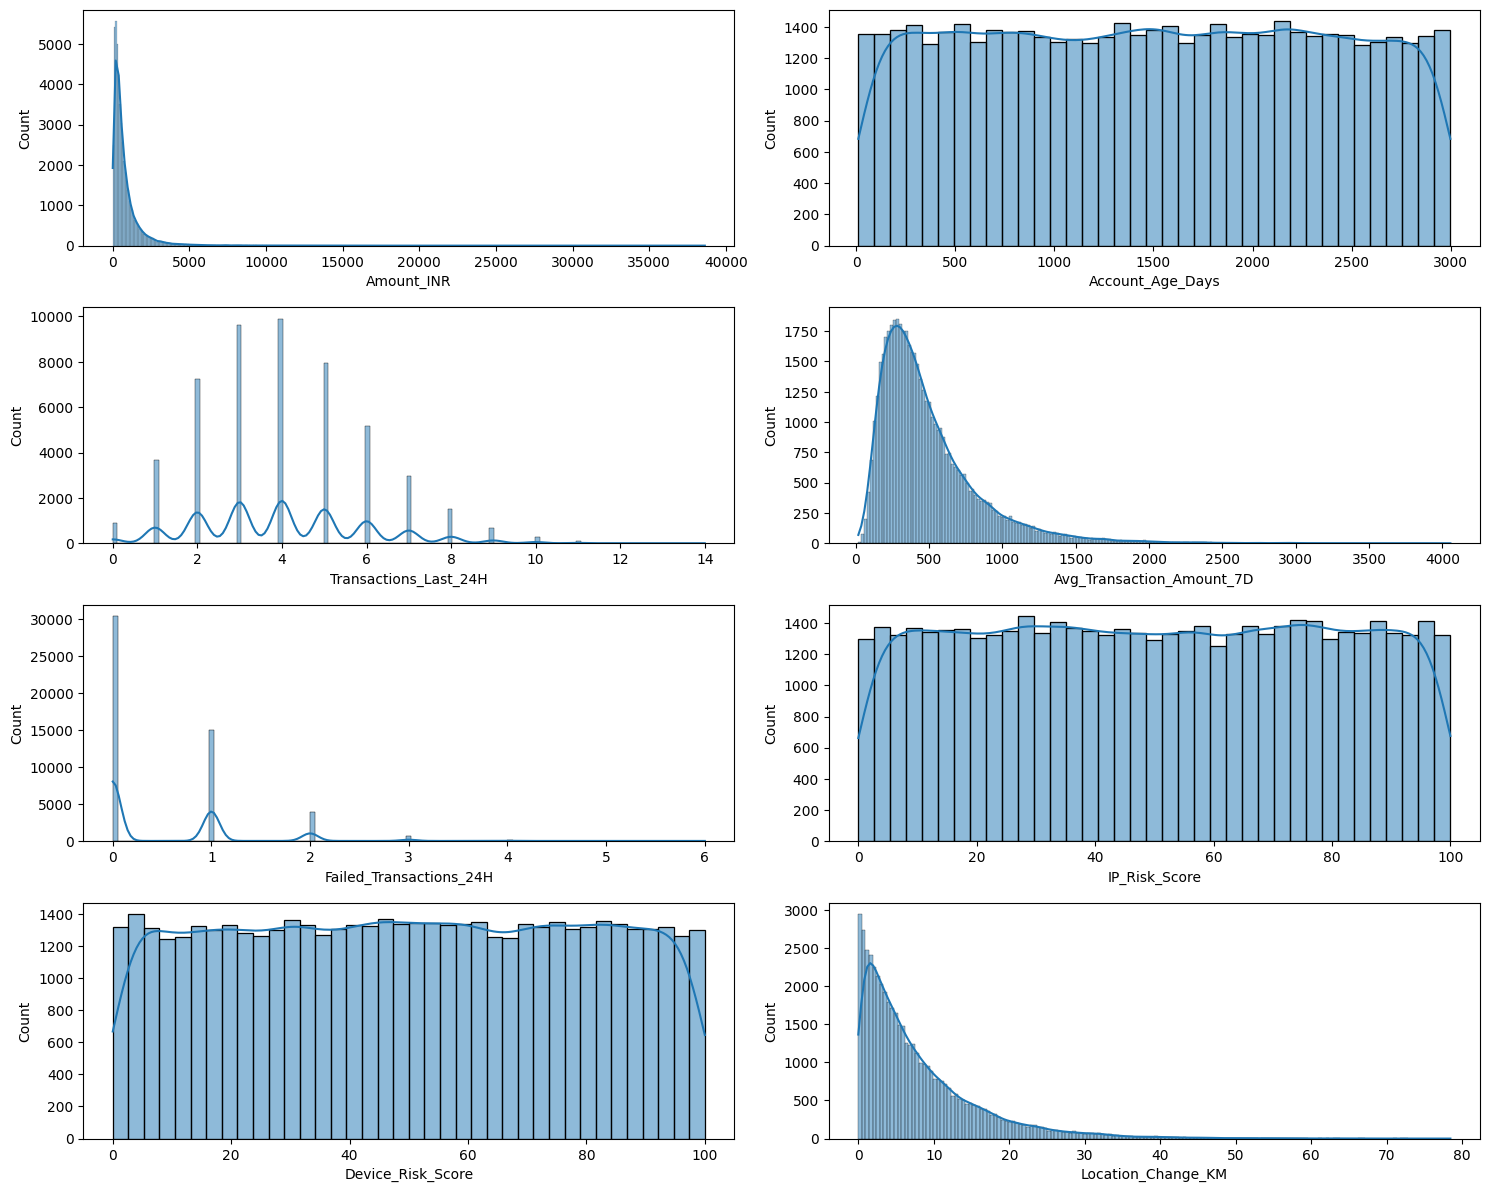

In [61]:
numeric_cols = ['Amount_INR', 'Account_Age_Days', 'Transactions_Last_24H',
       'Avg_Transaction_Amount_7D', 'Failed_Transactions_24H', 'IP_Risk_Score',
       'Device_Risk_Score', 'Location_Change_KM',]
plt.figure(figsize=(15,15))

for index, i in enumerate(numeric_cols):
    plt.subplot(5,2,index+3)
    sns.histplot(data=df, x=i, kde=True)

plt.tight_layout()
plt.show()

### Bivariate Analysis

<Axes: >

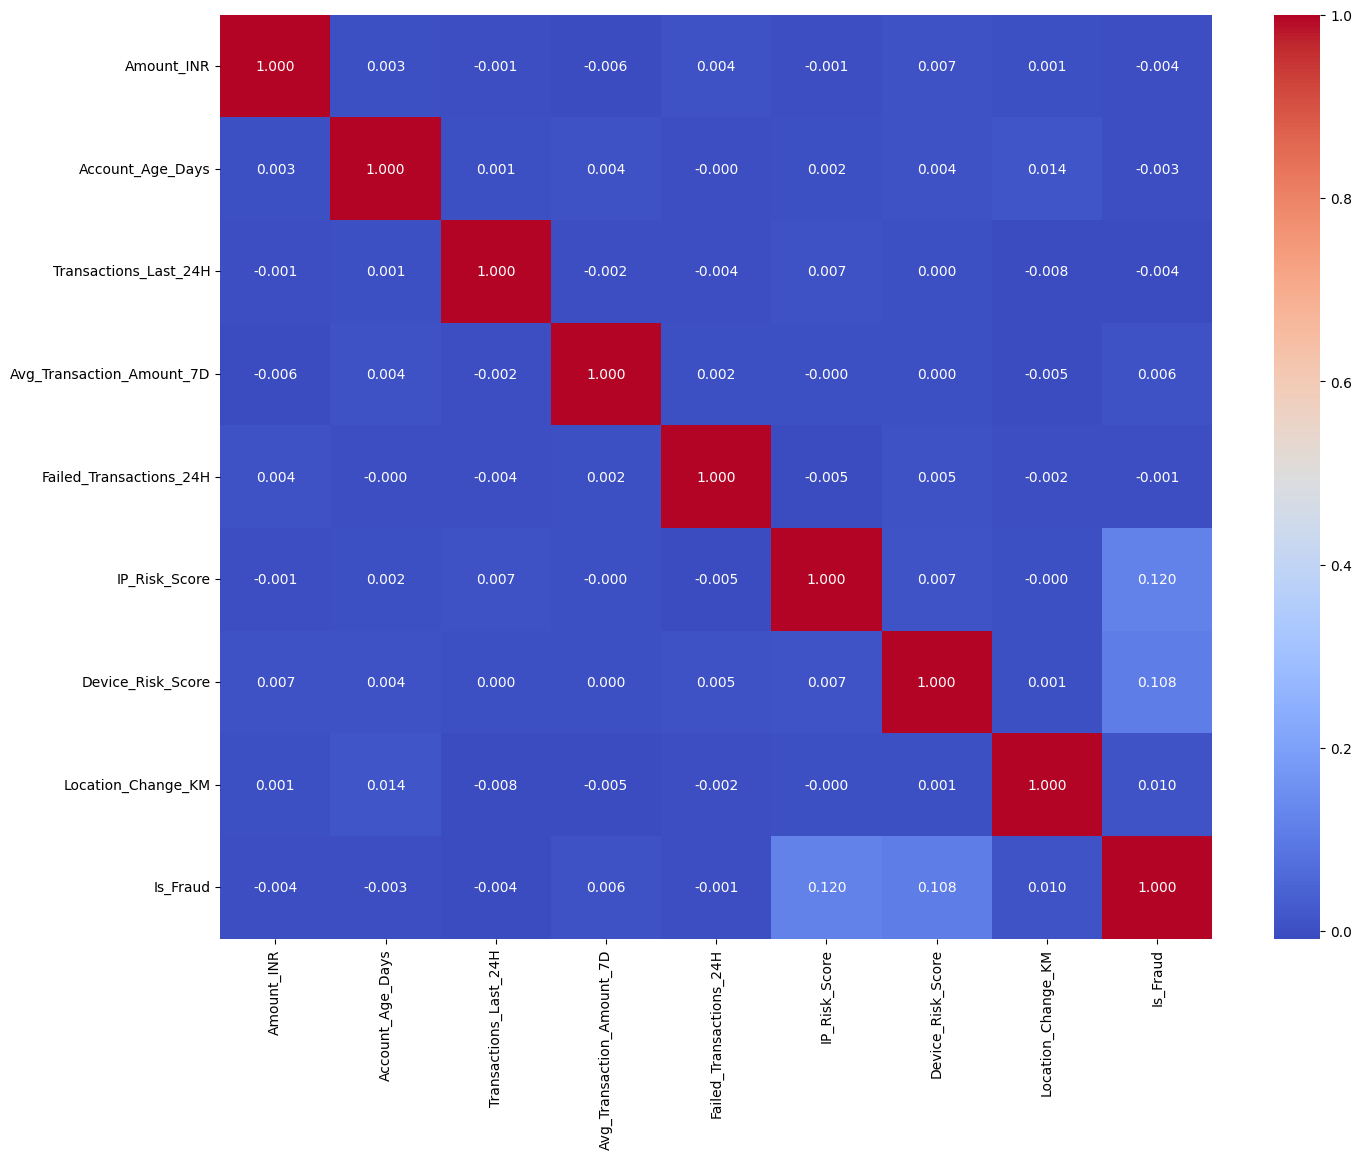

In [62]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True ,fmt=".3f", cmap="coolwarm" )

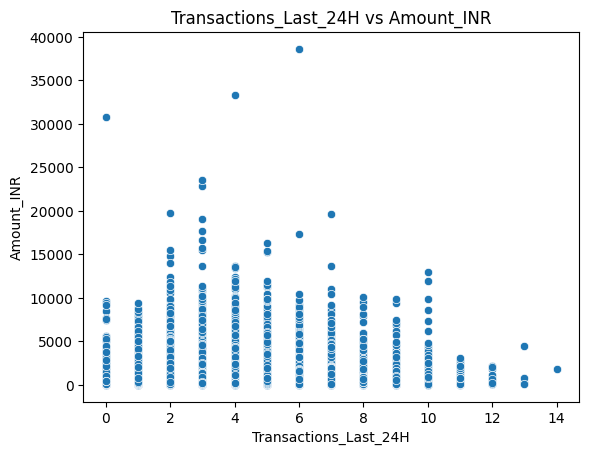

In [63]:
sns.scatterplot(data=df ,x='Transactions_Last_24H',y= 'Amount_INR' )
plt.title('Transactions_Last_24H vs Amount_INR')
plt.show()

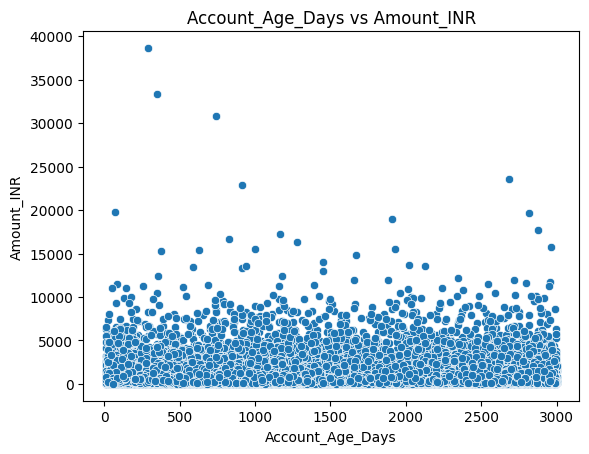

In [64]:
sns.scatterplot(data=df ,x='Account_Age_Days',y= 'Amount_INR' )
plt.title('Account_Age_Days vs Amount_INR')
plt.show()

### Numeric vs Category

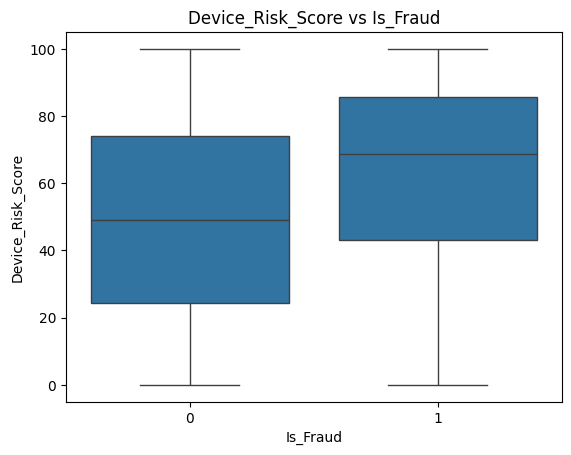

In [65]:
sns.boxplot(data=df ,x='Is_Fraud',y= 'Device_Risk_Score' )
plt.title('Device_Risk_Score vs Is_Fraud')
plt.show()

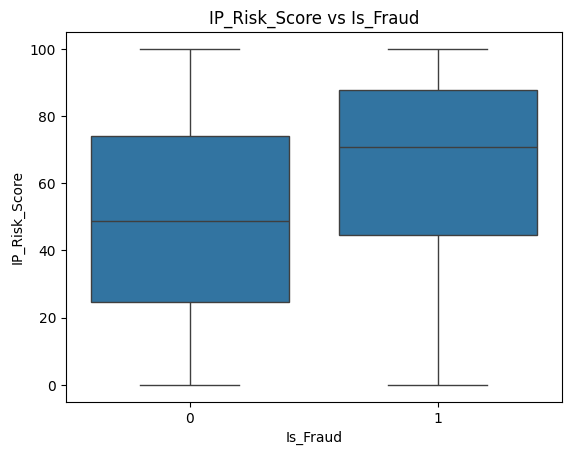

In [66]:
sns.boxplot(data=df ,x='Is_Fraud',y= 'IP_Risk_Score' )
plt.title('IP_Risk_Score vs Is_Fraud')
plt.show()

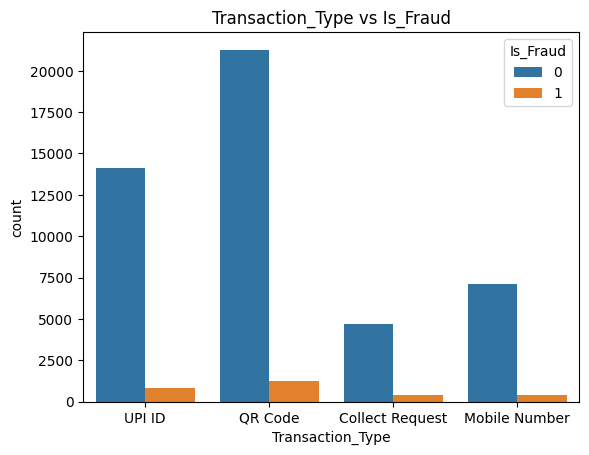

In [67]:
sns.countplot(data=df ,x='Transaction_Type',hue= 'Is_Fraud' )
plt.title('Transaction_Type vs Is_Fraud')
plt.show()

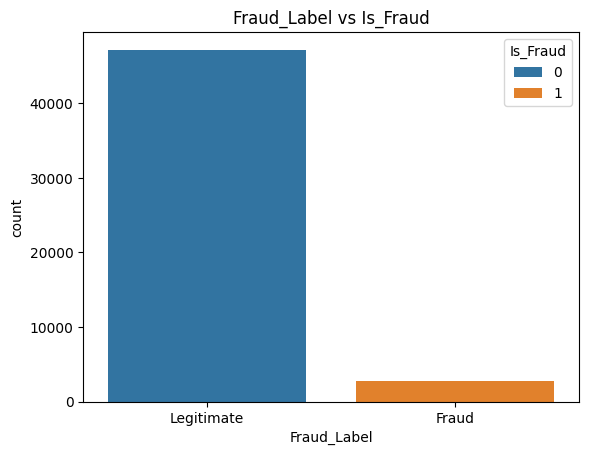

In [68]:
sns.countplot(data=df ,x='Fraud_Label',hue= 'Is_Fraud' )
plt.title('Fraud_Label vs Is_Fraud')
plt.show()

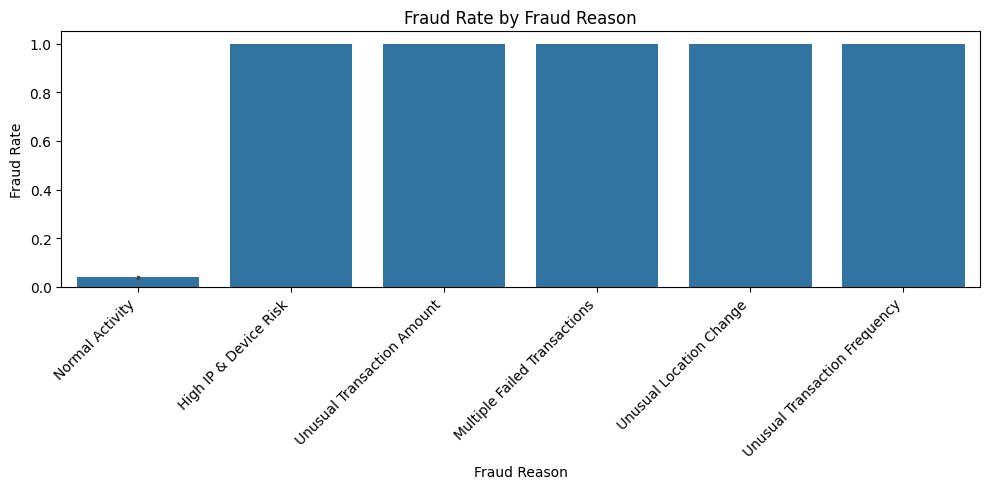

In [69]:
plt.figure(figsize=(10, 5))

sns.barplot(  data=df,  x='Fraud_Reason',   y='Is_Fraud')
plt.title('Fraud Rate by Fraud Reason')
plt.xlabel('Fraud Reason')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Category vs Category

<Axes: xlabel='Device_Type', ylabel='count'>

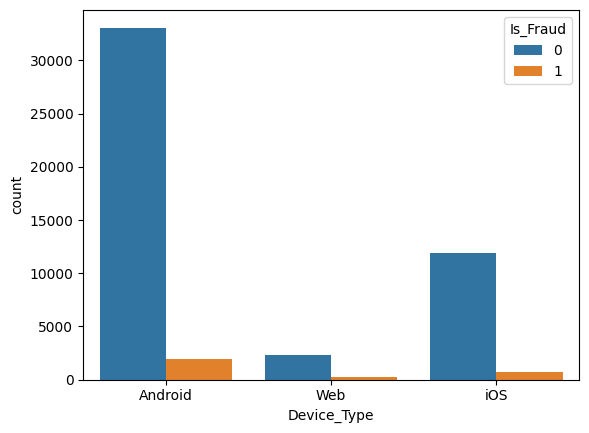

In [70]:
sns.countplot(df, x="Device_Type",hue='Is_Fraud')

<Axes: xlabel='Transaction_Type', ylabel='count'>

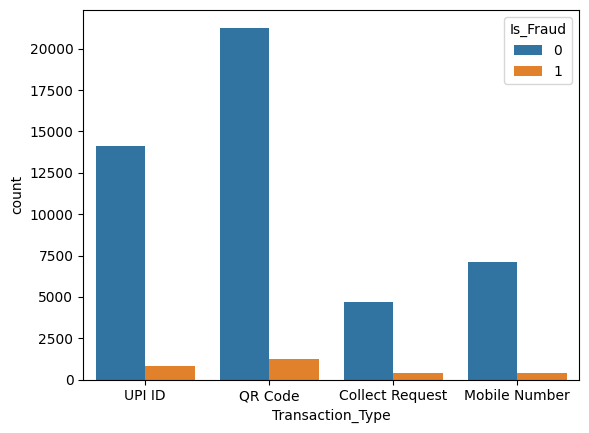

In [71]:
sns.countplot(df, x="Transaction_Type",hue='Is_Fraud')

<Axes: xlabel='Transaction_Status'>

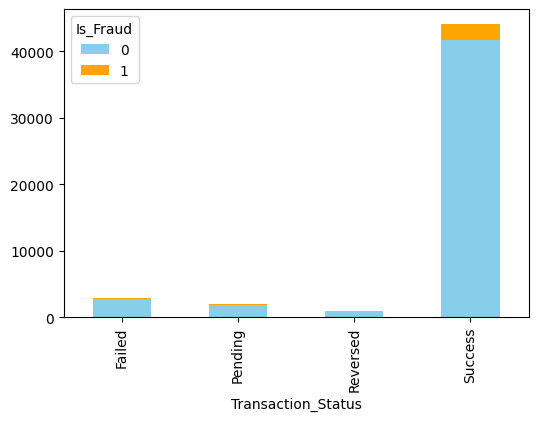

In [72]:
ct = pd.crosstab(df['Transaction_Status'], df['Is_Fraud'])
ct.plot(kind='bar',stacked=True,figsize=(6,4),color=['skyblue', 'orange'])

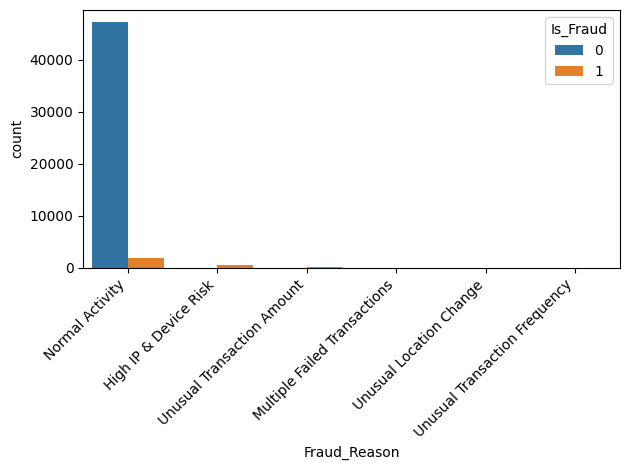

In [73]:
sns.countplot(df, x="Fraud_Reason",hue='Is_Fraud')
plt.xticks(rotation=45 , ha='right')
plt.tight_layout()
plt.show()

<Axes: xlabel='Fraud_Label'>

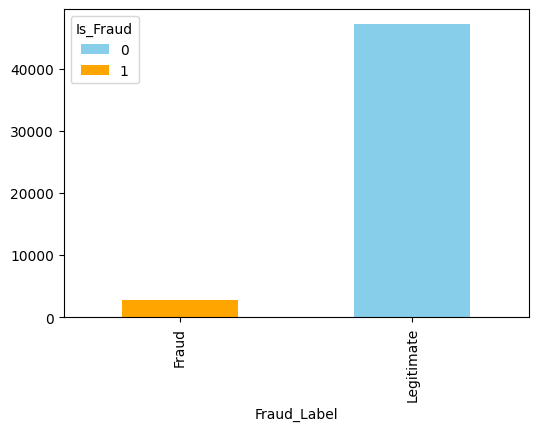

In [74]:
ct = pd.crosstab(df['Fraud_Label'], df['Is_Fraud'])
ct.plot(kind='bar',stacked=True,figsize=(6,4),color=['skyblue', 'orange'])

### Multivariate

[Text(0, 0, '484'),
 Text(0, 0, '50'),
 Text(0, 0, '1987'),
 Text(0, 0, '11'),
 Text(0, 0, '261'),
 Text(0, 0, '1'),
 Text(0, 0, '0')]

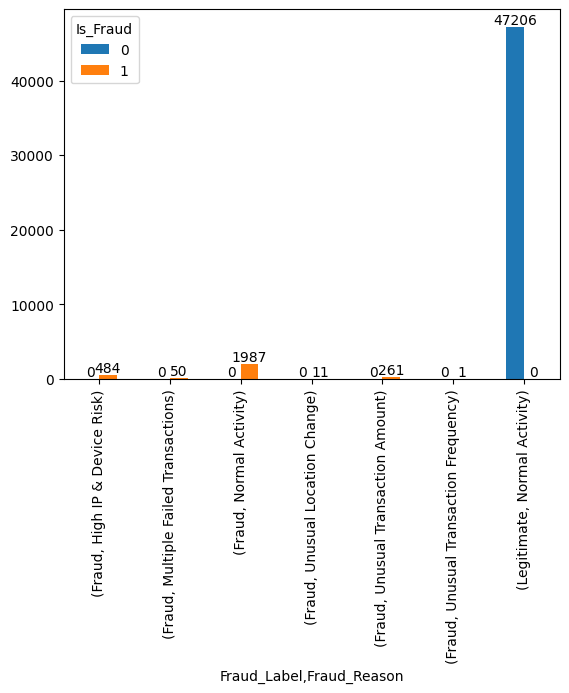

In [75]:
ax=df.groupby(["Fraud_Label", "Fraud_Reason" , "Is_Fraud"])["Is_Fraud"].count().unstack().plot.bar()
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

[Text(0, 0, '376'),
 Text(0, 0, '391'),
 Text(0, 0, '1217'),
 Text(0, 0, '810'),
 Text(0, 0, '0'),
 Text(0, 0, '0'),
 Text(0, 0, '0'),
 Text(0, 0, '0')]

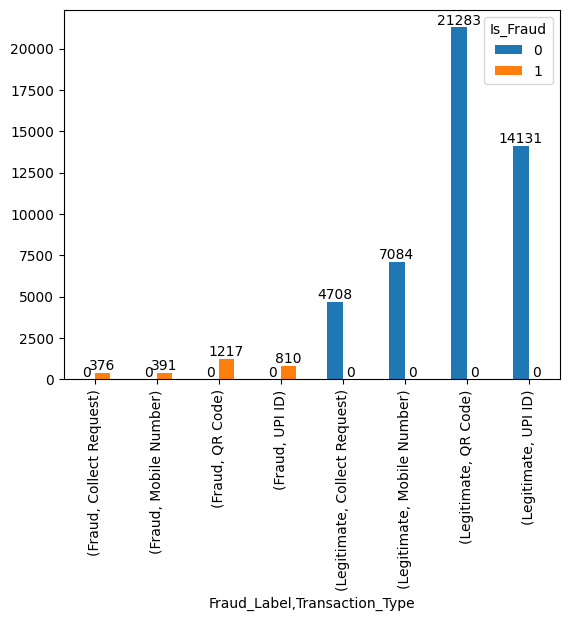

In [76]:
ax=df.groupby(["Fraud_Label", "Transaction_Type" , "Is_Fraud"])["Is_Fraud"].count().unstack().plot.bar()
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

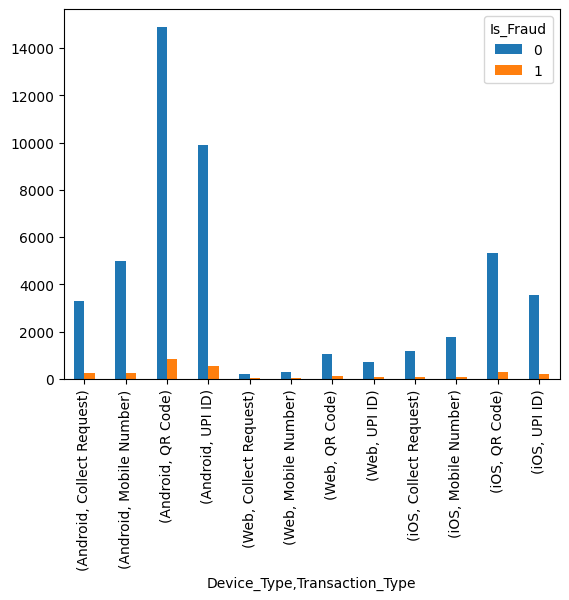

In [77]:
ax=df.groupby(["Device_Type", "Transaction_Type" , "Is_Fraud"])["Is_Fraud"].count().unstack().plot.bar()

<Figure size 1500x1200 with 0 Axes>

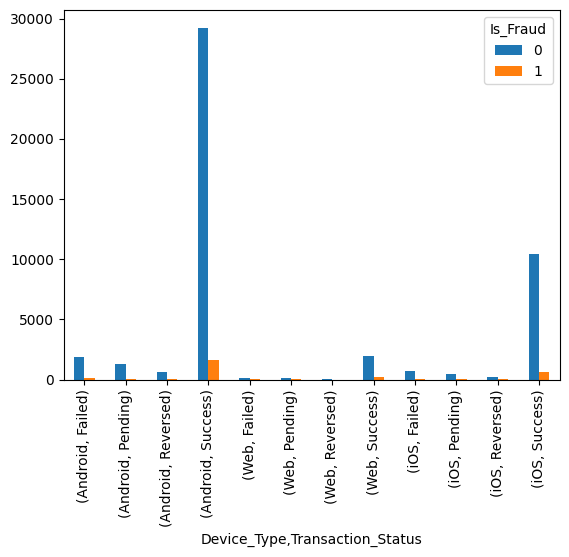

<Figure size 1500x1200 with 0 Axes>

In [78]:
ax=df.groupby(["Device_Type", "Transaction_Status" , "Is_Fraud"])["Is_Fraud"].count().unstack().plot.bar()
plt.figure(figsize=(15,12))

[Text(0, 0, '318'),
 Text(0, 0, '35'),
 Text(0, 0, '1346'),
 Text(0, 0, '8'),
 Text(0, 0, '188'),
 Text(0, 0, '50'),
 Text(0, 0, '3'),
 Text(0, 0, '158'),
 Text(0, 0, '1'),
 Text(0, 0, '16'),
 Text(0, 0, '116'),
 Text(0, 0, '12'),
 Text(0, 0, '483'),
 Text(0, 0, '2'),
 Text(0, 0, '57'),
 Text(0, 0, '1')]

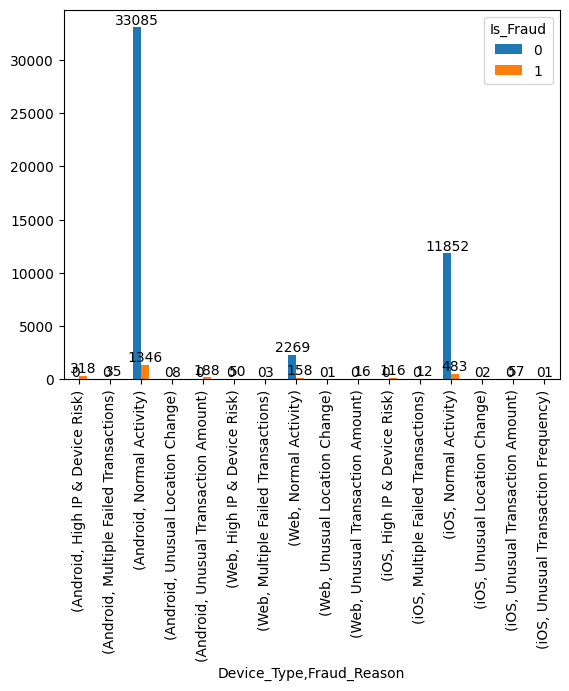

In [79]:
ax=df.groupby(["Device_Type", "Fraud_Reason" , "Is_Fraud"])["Is_Fraud"].count().unstack().plot.bar()
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

[Text(0, 0, '484'),
 Text(0, 0, '50'),
 Text(0, 0, '1987'),
 Text(0, 0, '11'),
 Text(0, 0, '261'),
 Text(0, 0, '1'),
 Text(0, 0, '0')]

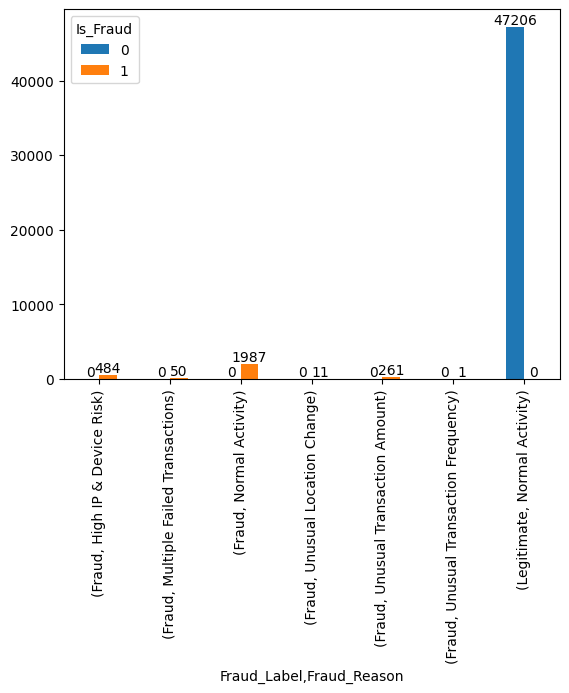

In [80]:
ax=df.groupby(["Fraud_Label", "Fraud_Reason" , "Is_Fraud"])["Is_Fraud"].count().unstack().plot.bar()
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])